In [1]:
### Diagnostic — Label distribution (Gold Standard only)
import matplotlib.pyplot as plt

import matplotlib.ticker as mticker
from pathlib import Path     # Used for robust and cross-platform file path management
import pandas as pd     
import logging
from joblib import Parallel, delayed
import gc

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)

# Core columns to extract from Progenetix biosample summaries
BIOSAMPLE_COLS = [
    "biosample_id", "individual_id", "analysis_id",
    "platform_id", "histological_diagnosis_id",
    "icdo_topography_id", "icdo_morphology_id",
    "pathological_stage_id", "sample_origin_type_id",
    "cohorts"
]

# Raw Data Inputs (Downloads folder)
DOWNLOADS_DIR     = Path("/Users/bgadmin/Downloads/")
BIOSAMPLE_SUMMARY = DOWNLOADS_DIR / "biosample_summary.csv"
GENE_PANEL        = DOWNLOADS_DIR / "gene_cnv_cancer_panel.tsv"
ILLUMINA_MANIFEST = DOWNLOADS_DIR / "infinium-methylationepic-v-1-0-b5-manifest-file.csv"
NCBI_GENE_INFO    = Path("/Users/bgadmin/Downloads/Homo_sapiens.gene_info")

# Intermediate Storage (Raw Omics)
GDC_RNA_INPUT    = Path("cohort_matrices")
GDC_METH_INPUT   = Path("cohort_methylation_matrices")
CBIO_BASE_INPUT  = Path("cbioportal_data")
PROGENETIX_RAW   = Path("progenetix_cnv")

# Cleaned Data Folders
GDC_CLEAN_OUTPUT  = Path("cohort_matrices_cleaned")
CBIO_CLEAN_OUTPUT = Path("cbioportal_cleaned")

# CNV bridge ID
OUTPUT_BRIDGE     = Path("cnv_id_bridge.csv")

# Mapping & Final Results
METADATA_FILE    = "all_progenetix_metadata.csv"
CNV_FILE         = PROGENETIX_RAW / "GLOBAL_cnv_gene_panel.parquet"
CNV_BRIDGE       = Path("cnv_id_bridge.csv")

# Cleaned directories for Joining
GDC_RNA_DIR      = GDC_CLEAN_OUTPUT / "rnaseq/"
CBIO_RNA_DIR     = CBIO_CLEAN_OUTPUT / "rnaseq/"
GDC_METH_DIR     = GDC_CLEAN_OUTPUT / "methylation/"
CBIO_METH_DIR    = CBIO_CLEAN_OUTPUT / "methylation/"


# ── FONCTIONS UTILITAIRES DE CHARGEMENT PARALLÈLE ────────────────────────────

def load_csv(f: Path, sep=None) -> tuple[str, pd.DataFrame]:
    """Charge un CSV en détectant automatiquement le séparateur."""
    if sep is None:
        with open(f) as fh:
            first_line = fh.readline()
        sep = "\t" if first_line.count("\t") > first_line.count(",") else ","
    
    df = pd.read_csv(f, index_col=0, sep=sep, engine="pyarrow")
    return f.stem, df


def load_folder_parallel(folder: Path, pattern: str, stem_replace: str = "", n_jobs: int = -1):
    """Charge tous les CSV d'un dossier en parallèle."""
    files = sorted(folder.glob(pattern)) if folder.exists() else []
    if not files:
        print(f"  ✗ Aucun fichier trouvé : {folder}/{pattern}")
        return {}

    print(f"  Chargement de {len(files)} fichiers en parallèle...")
    results = Parallel(n_jobs=n_jobs, prefer="processes")(
        delayed(load_csv)(f) for f in files
    )

    matrices = {}
    for stem, df in results:
        key = stem.replace(stem_replace, "") if stem_replace else stem
        matrices[key] = df
        print(f"  ✓ {key} : {df.shape[0]} features × {df.shape[1]} samples")

    return matrices


# ===============================================================================
# 📊 BLOC 1 : CHARGEMENT GLOBAL DE TOUS LES FICHIERS
# ===============================================================================

print("=" * 60)
print("1. CHARGEMENT DU GOLD STANDARD")
print("=" * 60)
gold_path = sorted(Path(".").glob("gold_standard_20260512_1315.parquet"))
if not gold_path:
    raise FileNotFoundError("Aucun fichier gold_standard_*.parquet trouvé.")
df = pd.read_parquet(gold_path[-1])
log.info(f"Gold standard chargé : {df.shape[0]:,} samples × {df.shape[1]:,} colonnes")


print("\n" + "=" * 60)
print("2. CHARGEMENT DES DONNÉES LOCALES (PARALLÈLE)")
print("=" * 60)

print("\n── GDC RNA-seq ──")
gdc_rna_matrices = load_folder_parallel(
    GDC_RNA_INPUT, "*_STAR_counts_matrix.csv", "_STAR_counts_matrix"
)

print("\n── GDC Méthylation ──")
gdc_meth_matrices = load_folder_parallel(
    GDC_METH_INPUT, "*_methylation_beta_matrix.csv", "_methylation_beta_matrix"
)

print("\n── cBioPortal RNA-seq ──")
cbio_rna_matrices = load_folder_parallel(
    CBIO_BASE_INPUT / "rnaseq", "*.csv"
)

print("\n── cBioPortal Méthylation ──")
cbio_meth_matrices = load_folder_parallel(
    CBIO_BASE_INPUT / "methylation", "*.csv"
)

print("\n── CNV Progenetix ──")
cnv_global = None
cnv_global_path = PROGENETIX_RAW / "GLOBAL_cnv_gene_panel.csv"
if cnv_global_path.exists():
    cnv_global = pd.read_csv(cnv_global_path, low_memory=False)
    print(f"  ✓ GLOBAL_cnv : {cnv_global.shape[0]} lignes × {cnv_global.shape[1]} colonnes")
elif CNV_FILE.exists():
    cnv_global = pd.read_parquet(CNV_FILE)
    print(f"  ✓ GLOBAL_cnv (parquet) : {cnv_global.shape[0]} lignes × {cnv_global.shape[1]} colonnes")
else:
    print(f"  ✗ CNV introuvable → lance run_CNV()")

# Nettoyage mémoire préventif après chargement massif
gc.collect()

1. CHARGEMENT DU GOLD STANDARD


2026-05-18 14:25:42,702 [INFO] Gold standard chargé : 9,574 samples × 6,111 colonnes



2. CHARGEMENT DES DONNÉES LOCALES (PARALLÈLE)

── GDC RNA-seq ──
  Chargement de 33 fichiers en parallèle...


/Users/bgadmin/Github/internship_zurich_2026/venv_omics/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  ✓ TCGA-ACC : 60660 features × 79 samples
  ✓ TCGA-BLCA : 60660 features × 428 samples
  ✓ TCGA-BRCA : 60660 features × 1230 samples
  ✓ TCGA-CESC : 60660 features × 308 samples
  ✓ TCGA-CHOL : 60660 features × 44 samples
  ✓ TCGA-COAD : 60660 features × 524 samples
  ✓ TCGA-DLBC : 60660 features × 48 samples
  ✓ TCGA-ESCA : 60660 features × 198 samples
  ✓ TCGA-GBM : 60660 features × 391 samples
  ✓ TCGA-HNSC : 60660 features × 566 samples
  ✓ TCGA-KICH : 60660 features × 90 samples
  ✓ TCGA-KIRC : 60660 features × 614 samples
  ✓ TCGA-KIRP : 60660 features × 322 samples
  ✓ TCGA-LAML : 60660 features × 151 samples
  ✓ TCGA-LGG : 60660 features × 527 samples
  ✓ TCGA-LIHC : 60660 features × 423 samples
  ✓ TCGA-LUAD : 60660 features × 601 samples
  ✓ TCGA-LUSC : 60660 features × 562 samples
  ✓ TCGA-MESO : 60660 features × 87 samples
  ✓ TCGA-OV : 60660 features × 432 samples
  ✓ TCGA-PAAD : 60660 features × 183 samples
  ✓ TCGA-PCPG : 60660 features × 187 samples
  ✓ TCGA-PRAD : 606

188

2. STATISTIQUES GLOBALES
  Samples total                  9,574
  Patients uniques               9,512
  Types de cancer                182
  Cohortes distinctes            1
  Avec CNV                       9,574  (100.0%)
  Avec RNA                       9,574  (100.0%)
  Avec Méthylation               9,574  (100.0%)
  Complet (CNV+RNA+Meth)         9,574  (100.0%)

3. TOP DISTRIBUTIONS

TOP 30 — Types de cancer
--------------------------------------------------
histological_diagnosis_label
Ductal Breast Carcinoma                                                      717
Squamous Cell Lung Carcinoma                                                 447
Endometrial Endometrioid Adenocarcinoma                                      378
Clear Cell Renal Cell Carcinoma                                              355
Hepatocellular Carcinoma                                                     350
Thyroid Gland Papillary Carcinoma                                            340
Bladder Urothel

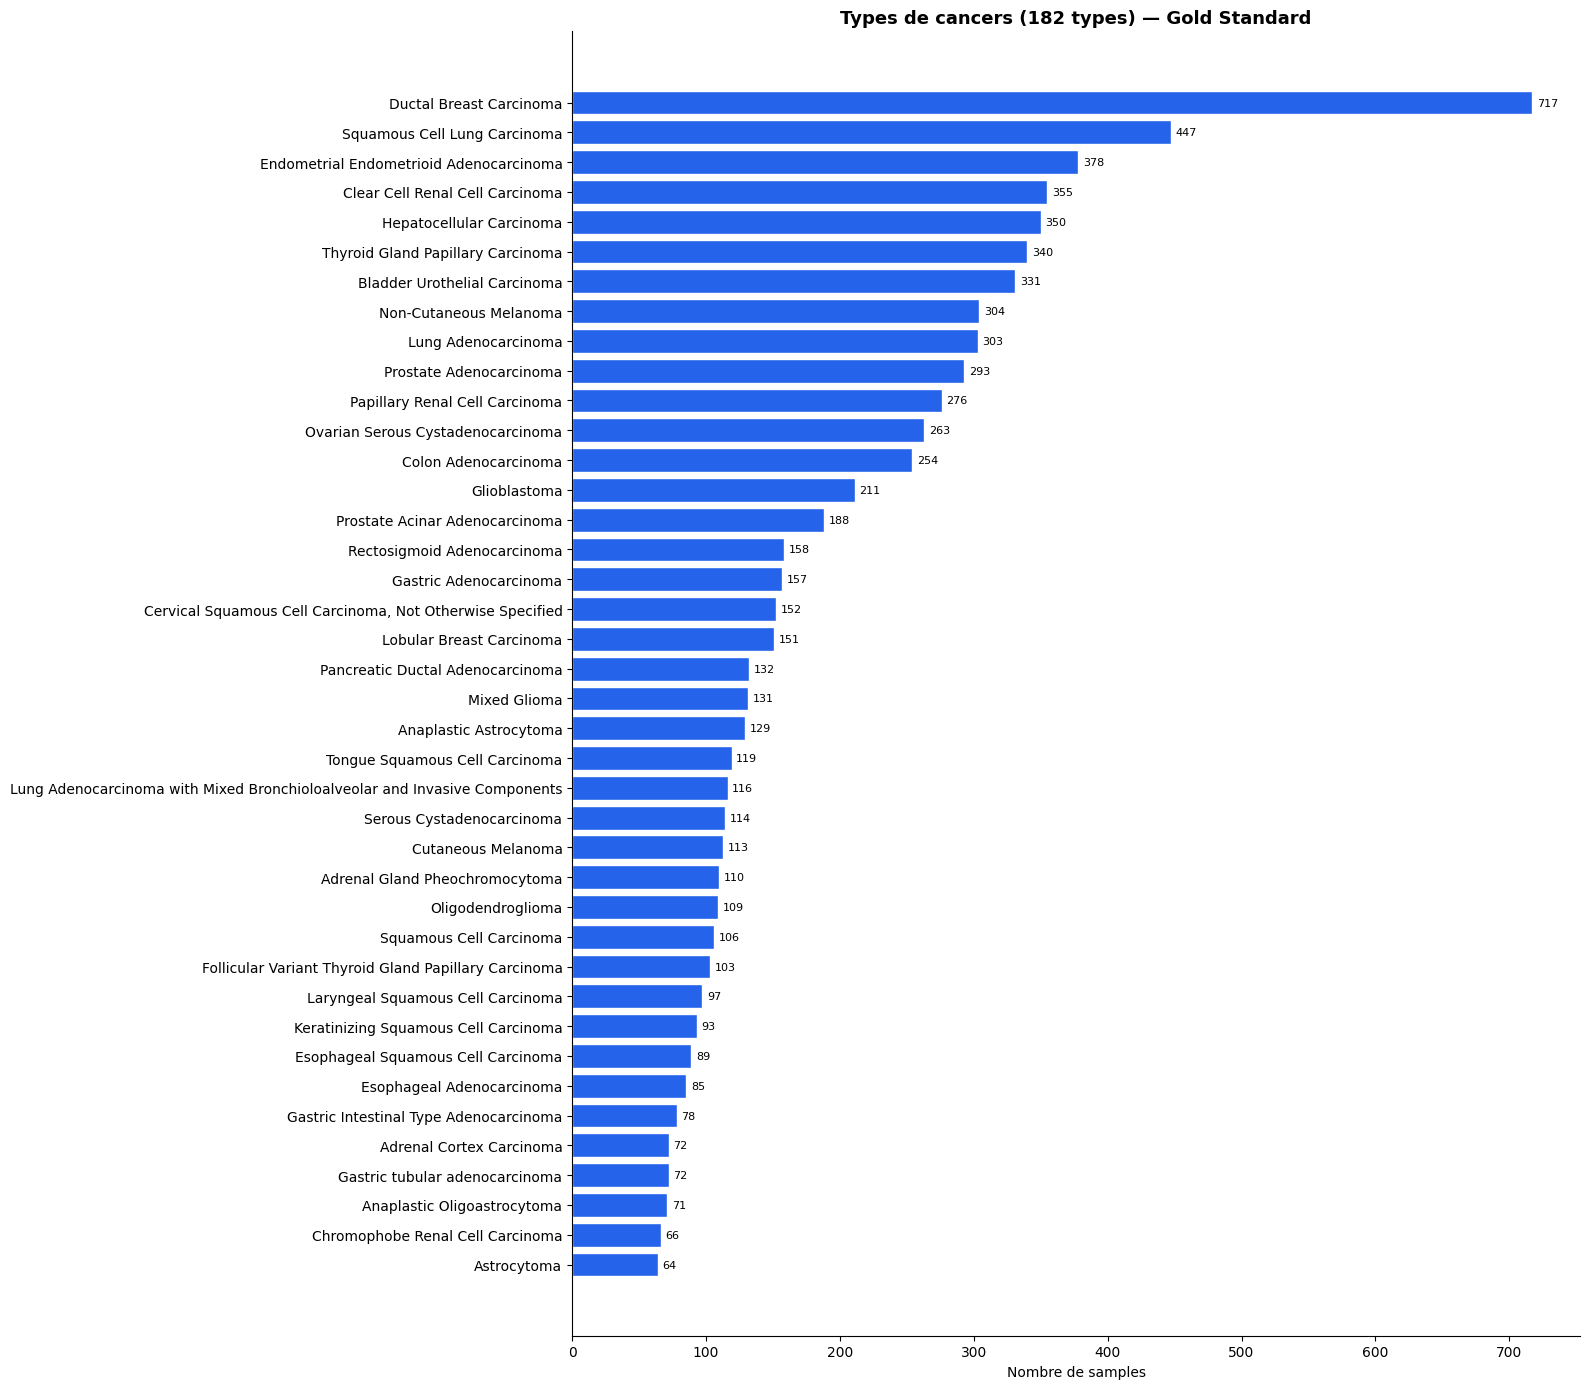

  Saved: Cohortes_1_distinctes_—_Gold_Standard.png


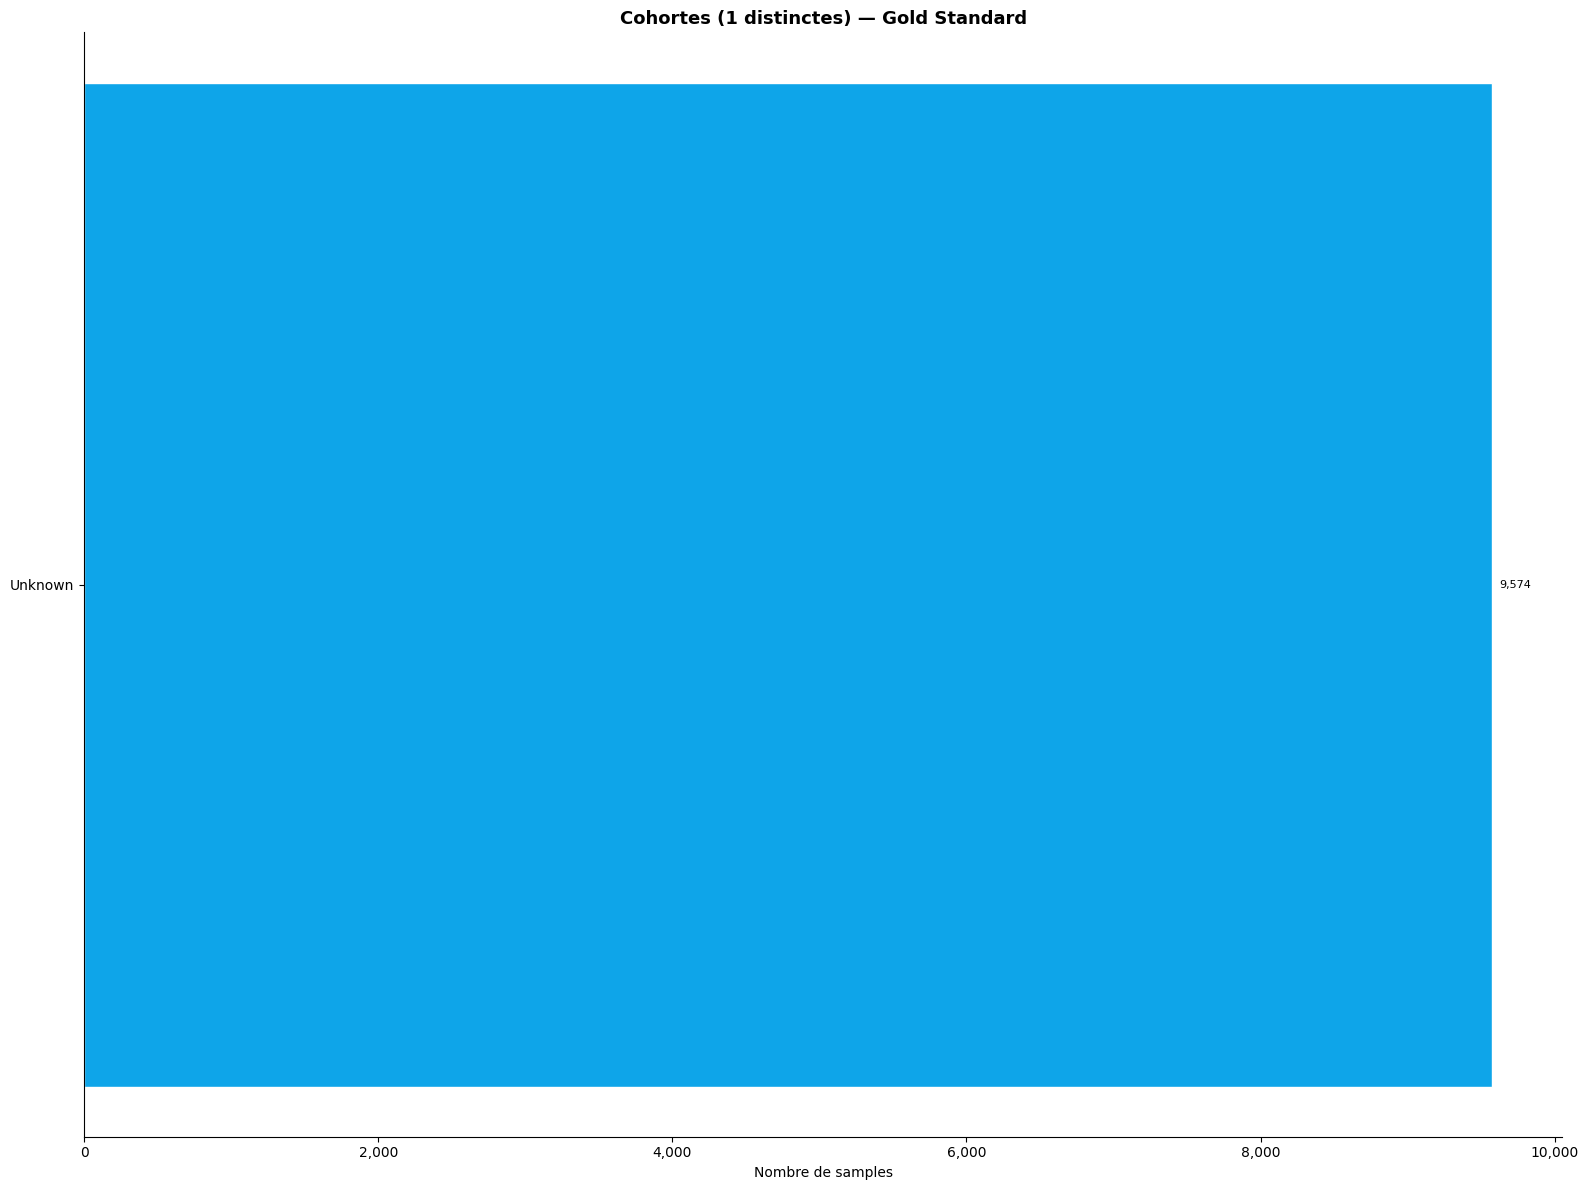

  Saved: cancer_distribution_omics_coverage.png


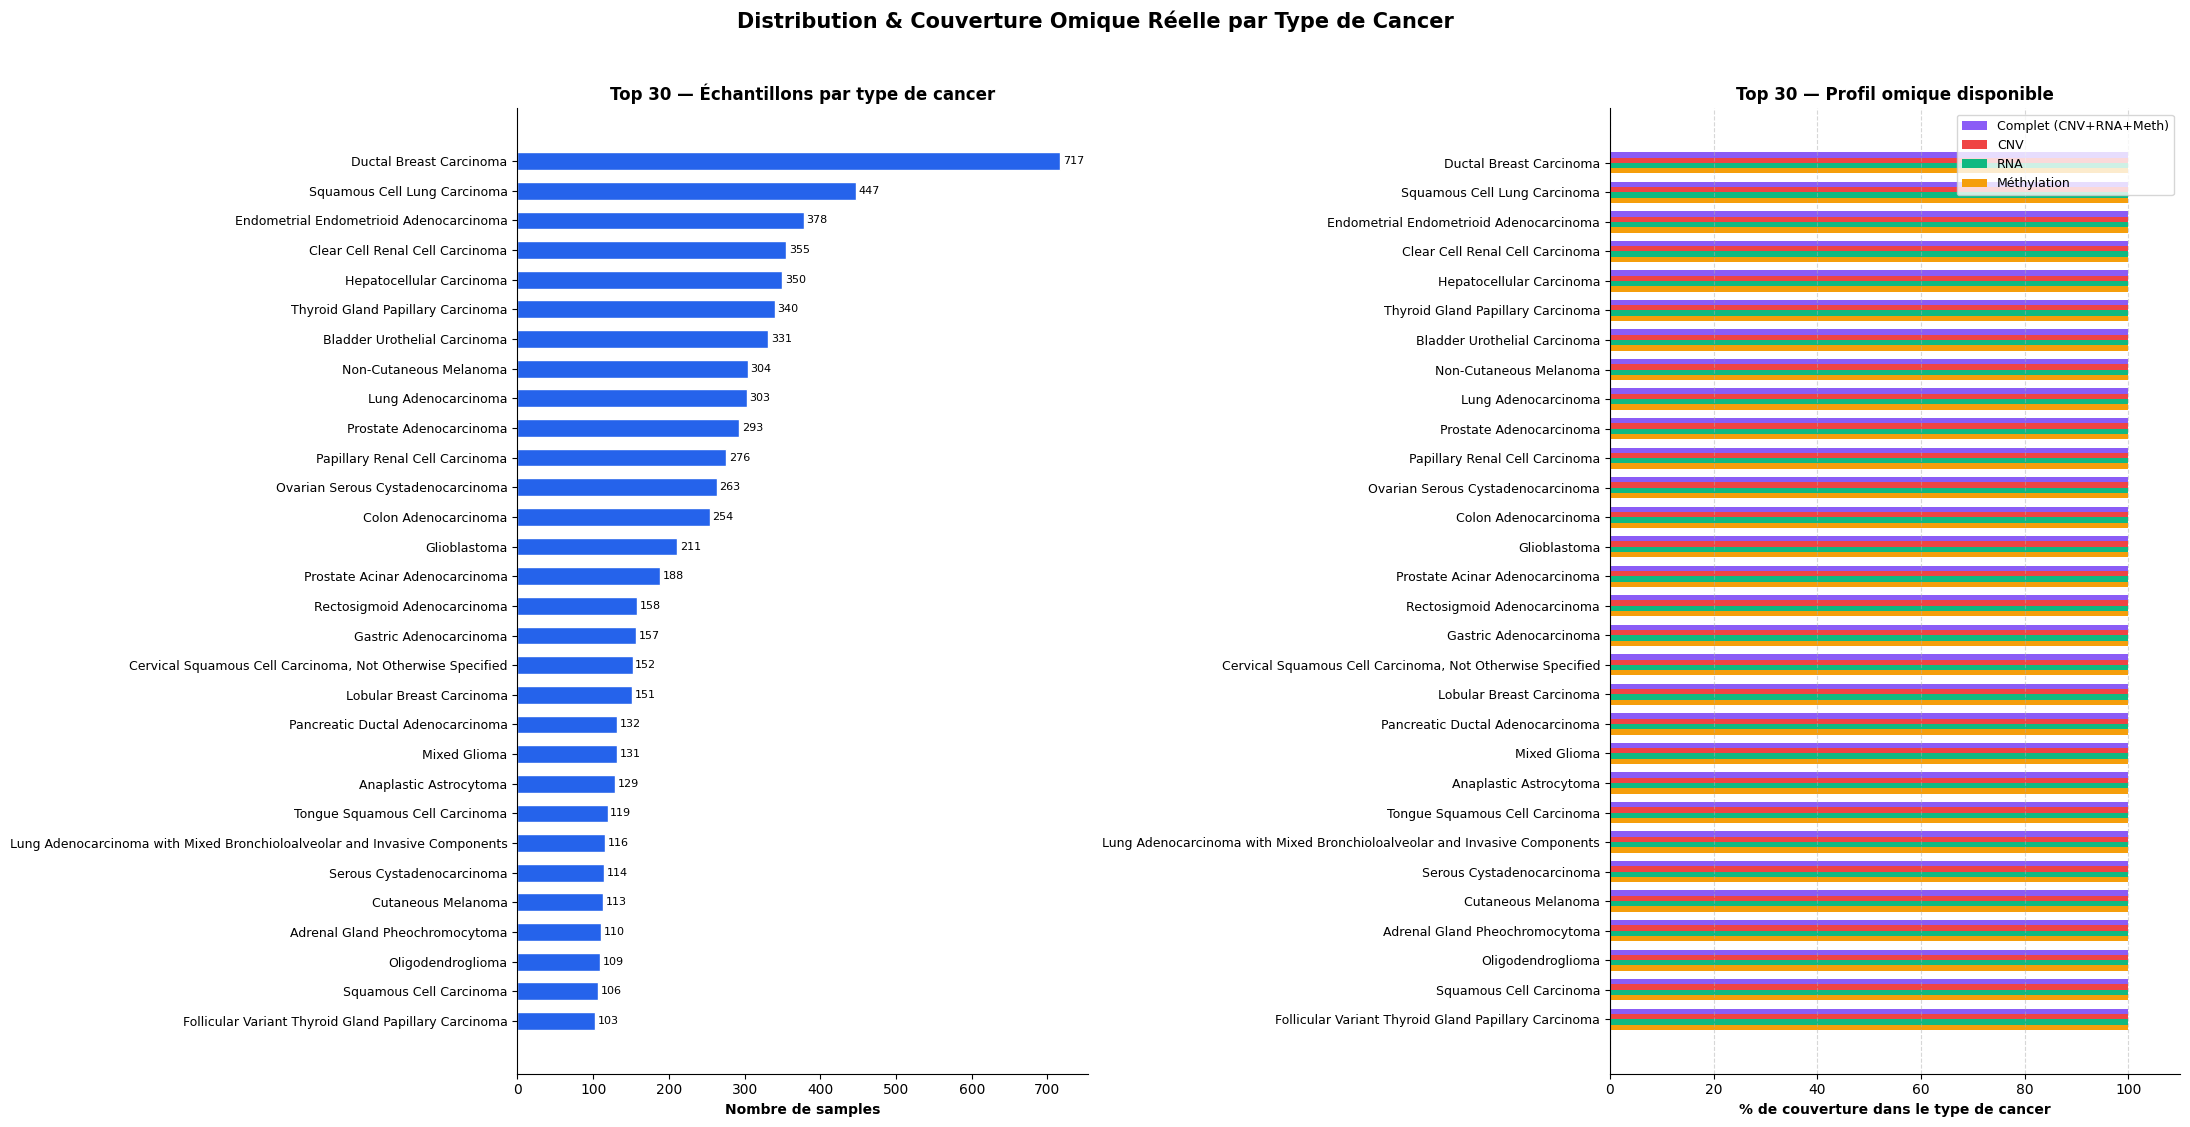

  Saved: cohort_coverage.png


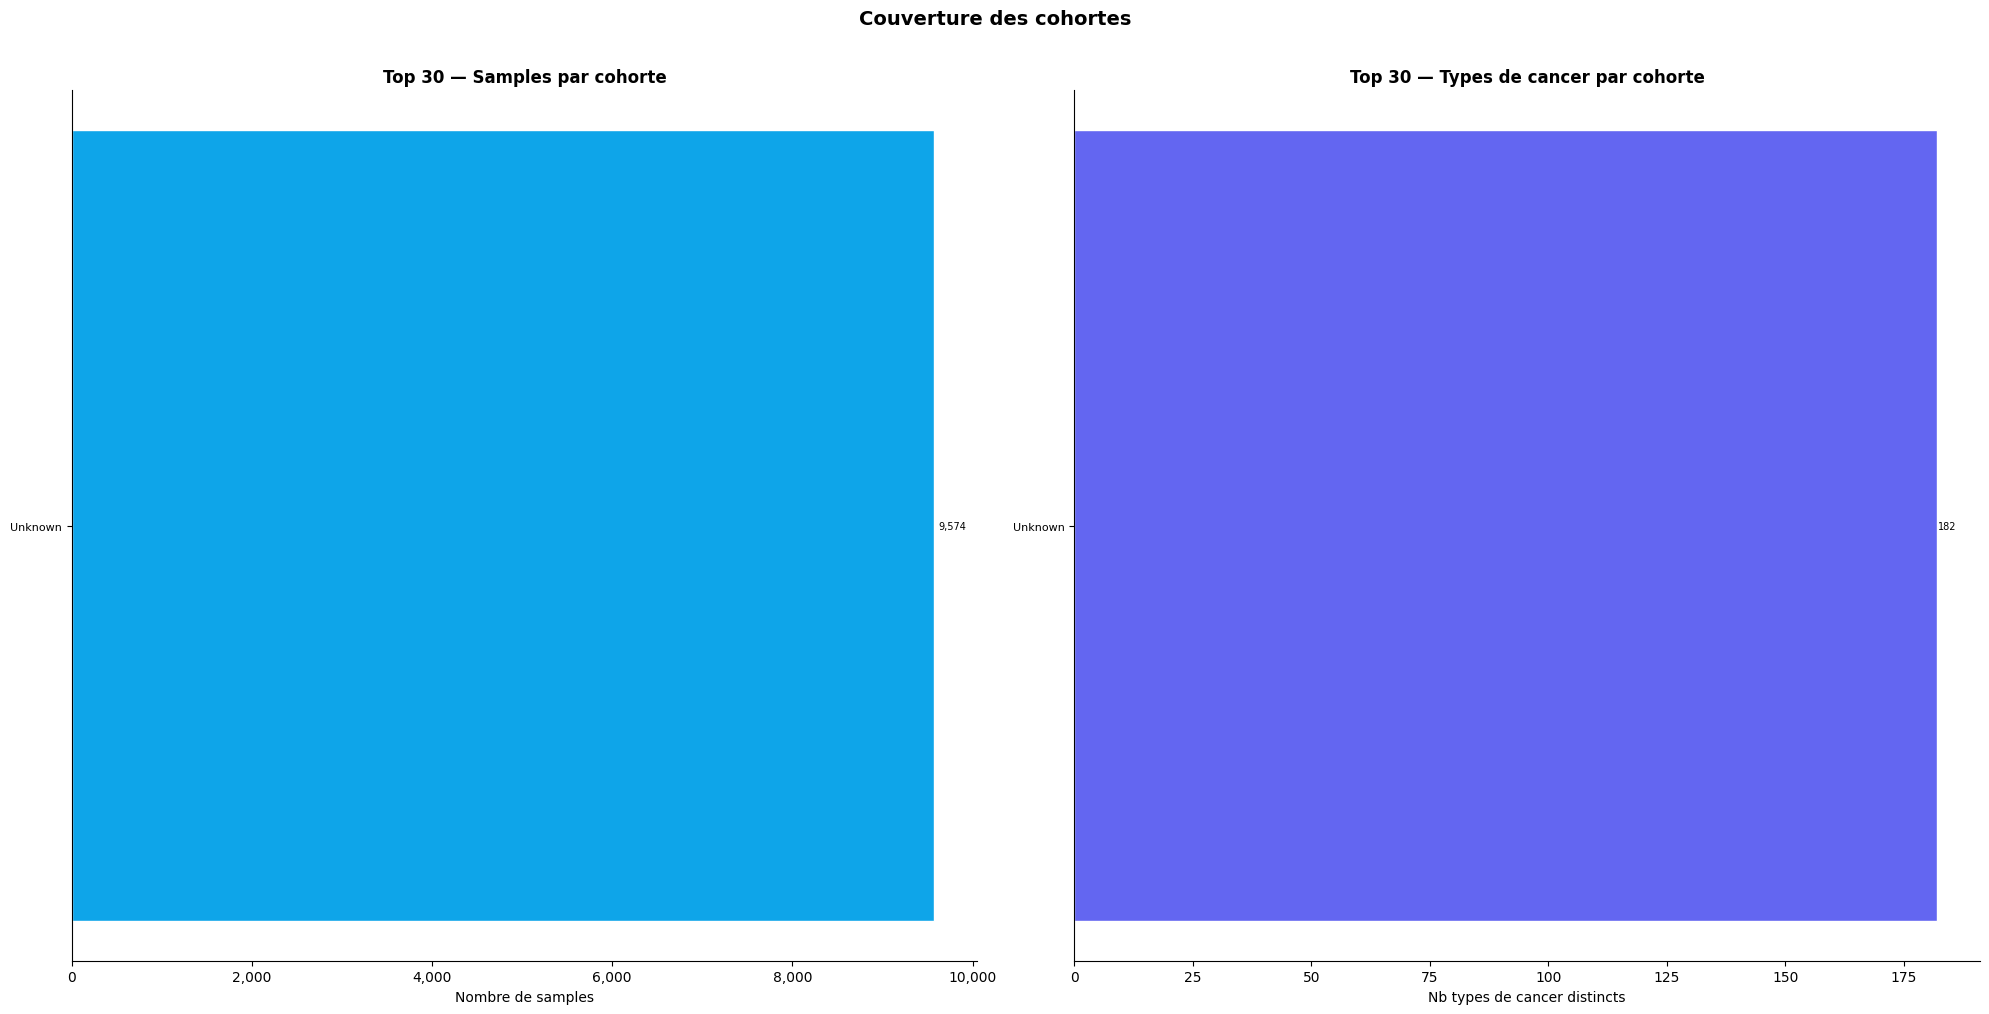

  Saved: cancer_vs_cohort_heatmap.png


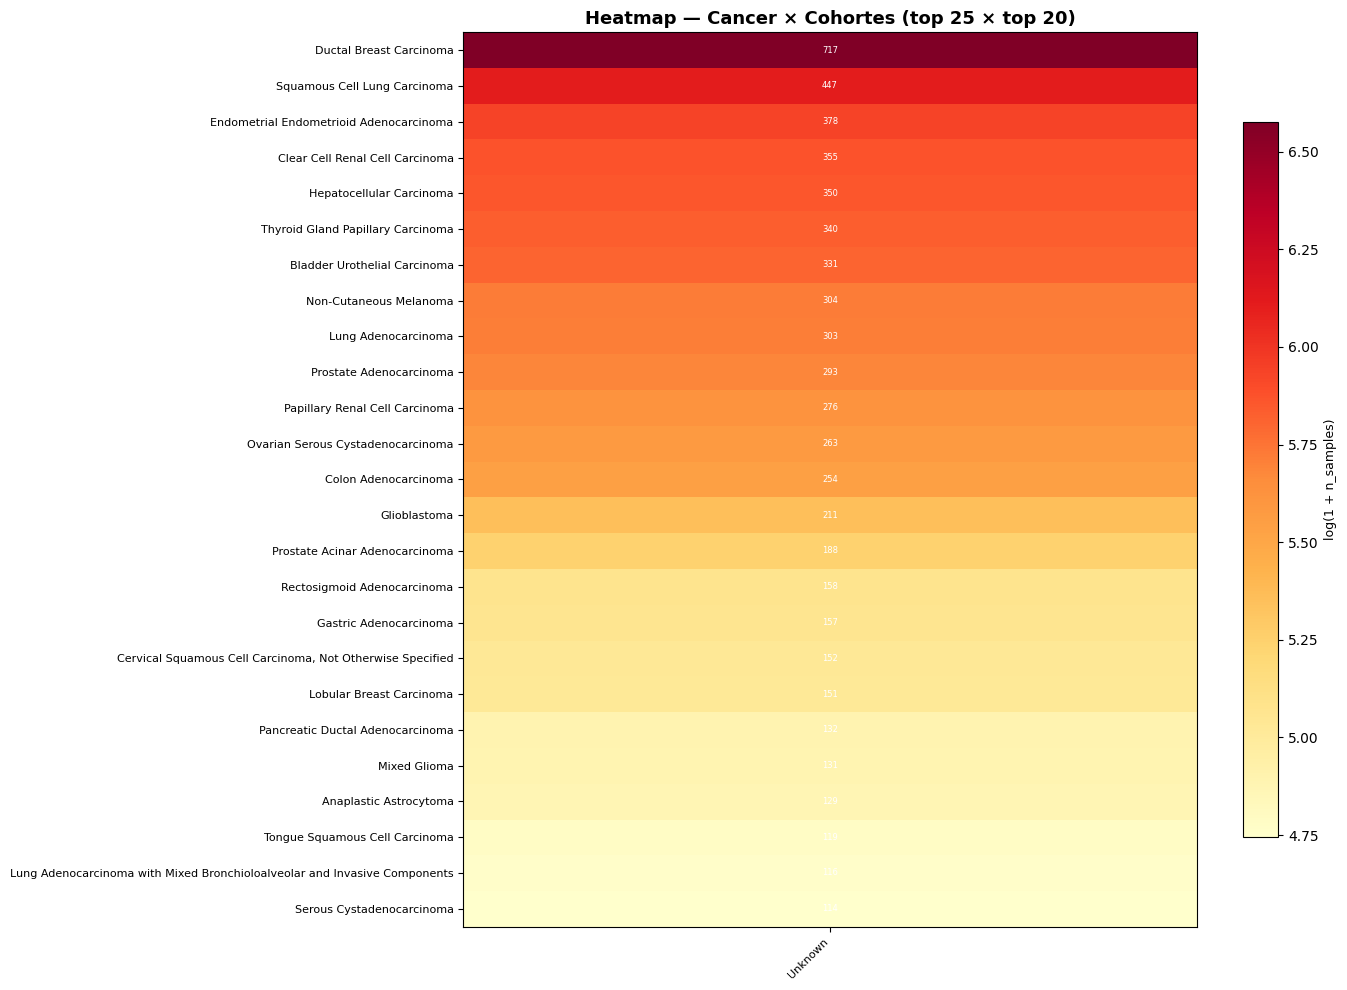

  Saved: omics_combinations.png


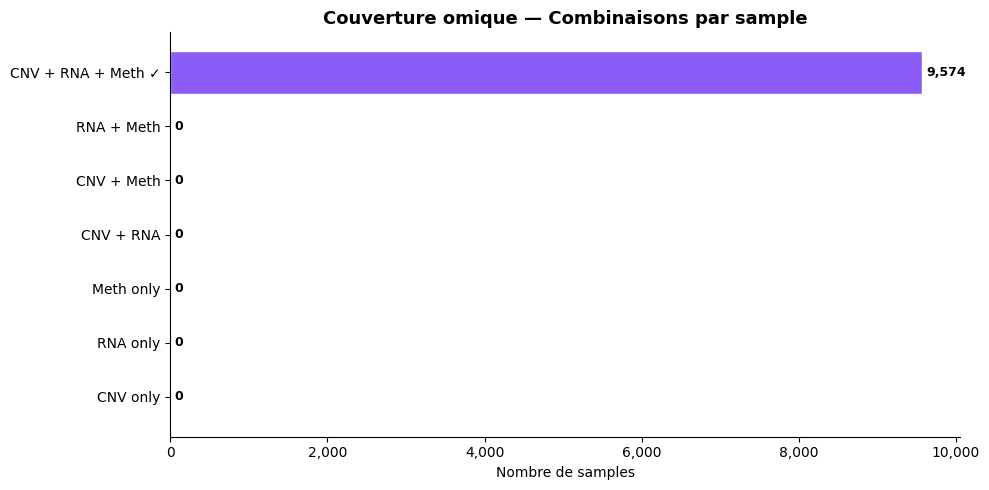

  Saved: ICDO_Morphologie.png


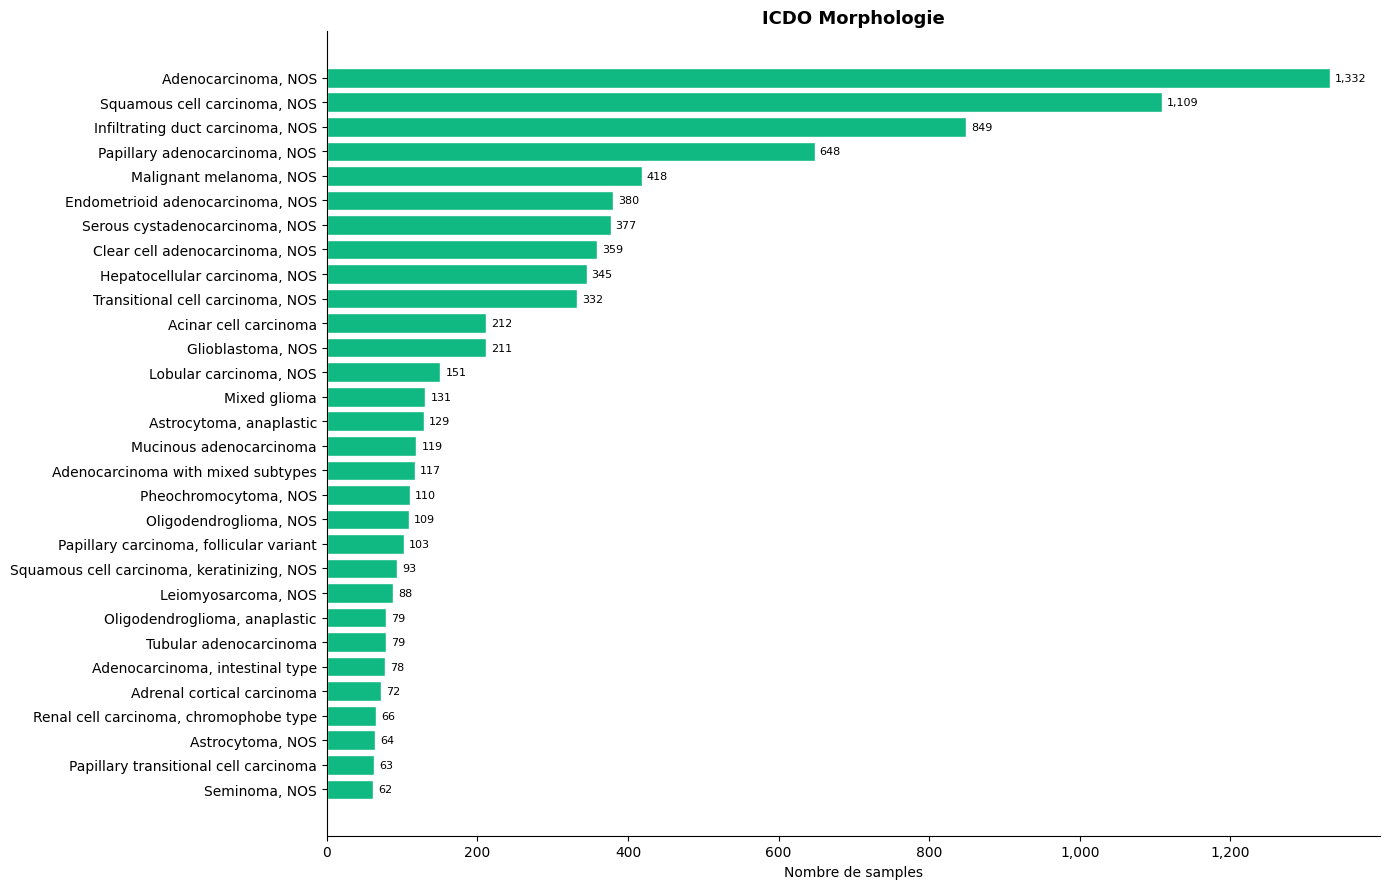

  Saved: ICDO_Topographie.png


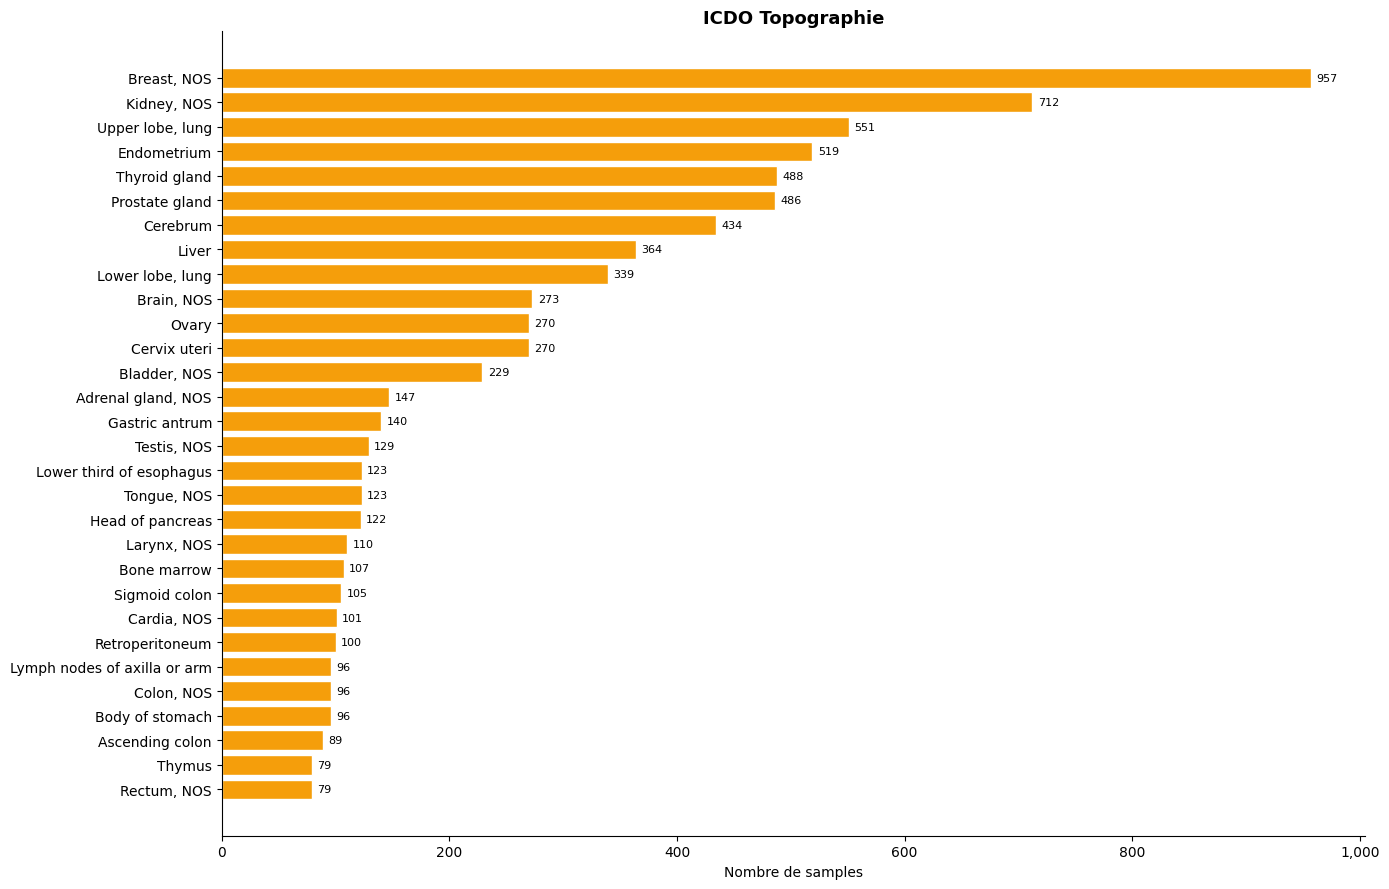

  Saved: Stades_pathologiques.png


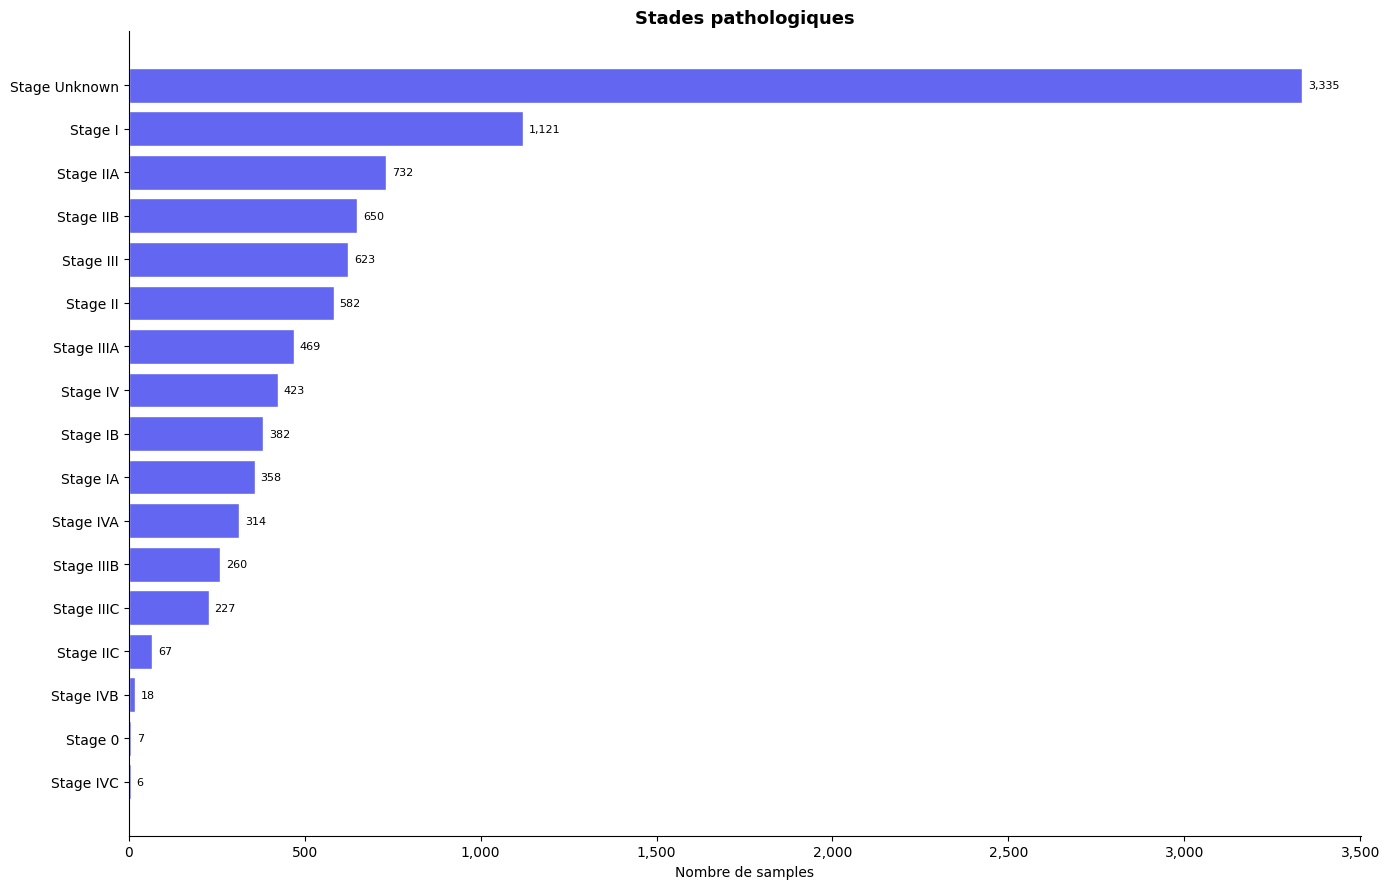


5. RÉSUMÉ FINAL
  Samples total                : 9,574
  Patients uniques             : 9,512
  Types de cancer              : 182
  Cohortes distinctes          : 1
  Avec CNV                     : 9,574  (100.0%)
  Avec RNA                     : 9,574  (100.0%)
    └─ GDC                     : 9,527
    └─ cBioPortal              : 47
  Avec Méthylation             : 9,574  (100.0%)
    └─ GDC                     : 9,527
    └─ cBioPortal              : 47
  Complet (CNV + RNA + Meth)   : 9,574  (100.0%)

  Fichiers CSV générés :
    • cancer_statistics.csv
    • cohort_statistics.csv
    • cancer_vs_cohort_table.csv

  Graphiques générés :
    • Types_de_cancers_*.png
    • Cohortes_*.png
    • cancer_distribution_omics_coverage.png
    • cohort_coverage.png
    • cancer_vs_cohort_heatmap.png
    • omics_combinations.png
    • ICDO_Morphologie.png
    • ICDO_Topographie.png
    • Stades_pathologiques.png

TERMINÉ


In [5]:
 
import ast
import gc
import logging
from pathlib import Path
 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
# =============================================================================
# 2.# ── Colonnes métadonnées ──────────────────────────────────────────────────────
CANCER_COL  = "histological_diagnosis_label"
MORPH_COL   = "icdo_morphology_label"
TOPO_COL    = "icdo_topography_label"
STAGE_COL   = "pathological_stage_label"
PATIENT_COL = "individual_id"
COHORT_COL  = "cohorts"
 
# ── Palette cohérente ─────────────────────────────────────────────────────────
COLOR_MAIN   = "#2563EB"   # bleu principal
COLOR_RNA    = "#10B981"   # vert  → RNA
COLOR_METH   = "#F59E0B"   # orange → Méthylation
COLOR_CNV    = "#EF4444"   # rouge  → CNV
COLOR_MULTI  = "#8B5CF6"   # violet → multiomique complet PARSE COHORTES
# =============================================================================
 
def parse_cohorts(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(str(x))
    except Exception:
        return []
 
if COHORT_COL in df.columns:
    df["cohorts_parsed"] = df[COHORT_COL].apply(parse_cohorts)
    df["cohort_names"] = df["cohorts_parsed"].apply(
        lambda L: [c.get("label", "Unknown") for c in L if isinstance(c, dict)]
    )
else:
    df["cohort_names"] = [[] for _ in range(len(df))]
 
exploded = df.explode("cohort_names")
exploded["cohort_names"] = exploded["cohort_names"].fillna("Unknown")
 
# =============================================================================
# 3. DÉTECTION DES COLONNES OMIQUES
# =============================================================================
cnv_cols       = [c for c in df.columns if c.startswith("cnv_")]
rna_gdc_cols   = [c for c in df.columns if c.startswith("rna_gdc_")]
rna_cbio_cols  = [c for c in df.columns if c.startswith("rna_cbio_")]
meth_gdc_cols  = [c for c in df.columns if c.startswith("meth_gdc_")]
meth_cbio_cols = [c for c in df.columns if c.startswith("meth_cbio_")]
rna_cols       = rna_gdc_cols  + rna_cbio_cols
meth_cols      = meth_gdc_cols + meth_cbio_cols
 
has_cnv   = df[cnv_cols].notna().any(axis=1)  if cnv_cols   else pd.Series(False, index=df.index)
has_rna   = df[rna_cols].notna().any(axis=1)  if rna_cols   else pd.Series(False, index=df.index)
has_meth  = df[meth_cols].notna().any(axis=1) if meth_cols  else pd.Series(False, index=df.index)
has_all   = has_cnv & has_rna & has_meth
 
# =============================================================================
# 4. STATISTIQUES GLOBALES
# =============================================================================
print("=" * 70)
print("2. STATISTIQUES GLOBALES")
print("=" * 70)
 
stats_lines = [
    ("Samples total",          f"{len(df):,}"),
    ("Patients uniques",       f"{df[PATIENT_COL].nunique():,}" if PATIENT_COL in df.columns else "N/A"),
    ("Types de cancer",        f"{df[CANCER_COL].nunique():,}" if CANCER_COL in df.columns else "N/A"),
    ("Cohortes distinctes",    f"{exploded['cohort_names'].nunique():,}"),
    ("Avec CNV",               f"{has_cnv.sum():,}  ({has_cnv.mean():.1%})"),
    ("Avec RNA",               f"{has_rna.sum():,}  ({has_rna.mean():.1%})"),
    ("Avec Méthylation",       f"{has_meth.sum():,}  ({has_meth.mean():.1%})"),
    ("Complet (CNV+RNA+Meth)", f"{has_all.sum():,}  ({has_all.mean():.1%})"),
]
for label, val in stats_lines:
    print(f"  {label:<30} {val}")
print()
 
# =============================================================================
# 5. TABLES DE FRÉQUENCES
# =============================================================================
print("=" * 70)
print("3. TOP DISTRIBUTIONS")
print("=" * 70)
 
for title, col, src in [
    ("TOP 30 — Types de cancer",   CANCER_COL, df),
    ("TOP 25 — Morphologie ICD-O", MORPH_COL,  df),
    ("TOP 25 — Topographie ICD-O", TOPO_COL,   df),
    ("TOP 20 — Stades",            STAGE_COL,  df),
    ("TOP 30 — Cohortes",          "cohort_names", exploded),
]:
    if col in src.columns:
        print(f"\n{title}")
        print("-" * 50)
        print(src[col].value_counts().head(30).to_string())
 
# =============================================================================
# 6. STATS PAR CANCER  (n_samples, n_patients, ratio)
# =============================================================================
if CANCER_COL in df.columns and PATIENT_COL in df.columns:
    stats_cancer = pd.DataFrame({
        "n_samples":  df.groupby(CANCER_COL).size(),
        "n_patients": df.groupby(CANCER_COL)[PATIENT_COL].nunique(),
    })
    stats_cancer["samples_per_patient"] = (
        stats_cancer["n_samples"] / stats_cancer["n_patients"]
    ).round(2)
    # Couverture omique par cancer
    stats_cancer["pct_cnv"]  = df.groupby(CANCER_COL).apply(
        lambda g: has_cnv[g.index].mean()
    ).round(3)
    stats_cancer["pct_rna"]  = df.groupby(CANCER_COL).apply(
        lambda g: has_rna[g.index].mean()
    ).round(3)
    stats_cancer["pct_meth"] = df.groupby(CANCER_COL).apply(
        lambda g: has_meth[g.index].mean()
    ).round(3)
    stats_cancer = stats_cancer.sort_values("n_samples", ascending=False)
    stats_cancer.to_csv("cancer_statistics.csv")
    print("\n\nStats par cancer sauvegardées → cancer_statistics.csv")
    print(stats_cancer.head(30).to_string())
 
# =============================================================================
# 7. STATS PAR COHORTE
# =============================================================================
cohort_stats = (
    exploded.groupby("cohort_names")
    .agg(
        n_samples=(CANCER_COL, "count"),
        n_cancer_types=(CANCER_COL, "nunique"),
    )
    .sort_values("n_samples", ascending=False)
)
cohort_stats.to_csv("cohort_statistics.csv")
print("\n\nStats par cohorte sauvegardées → cohort_statistics.csv")
print(cohort_stats.head(25).to_string())
 
# =============================================================================
# 8. CROSSTAB CANCER × COHORTE
# =============================================================================
cross = pd.crosstab(exploded[CANCER_COL], exploded["cohort_names"])
cross = cross.loc[cross.sum(axis=1).sort_values(ascending=False).index]
cross.to_csv("cancer_vs_cohort_table.csv")
print("\nCrosstab cancer × cohorte sauvegardée → cancer_vs_cohort_table.csv")
 
# =============================================================================
# 9. FONCTIONS GRAPHIQUES
# =============================================================================
 
def plot_bar(series, title, top_n=30, figsize=(14, 8), color=COLOR_MAIN):
    vc = series.value_counts(dropna=True).head(top_n)
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(vc.index[::-1], vc.values[::-1], color=color, edgecolor="white")
    for bar, val in zip(bars, vc.values[::-1]):
        ax.text(
            val + vc.values.max() * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,}",
            va="center", fontsize=8
        )
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Nombre de samples")
    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
    )
    plt.tight_layout()
    png = title.replace(" ", "_").replace("/", "-").replace("(", "").replace(")", "") + ".png"
    plt.savefig(png, dpi=150, bbox_inches="tight")
    print(f"  Saved: {png}")
    plt.show()
 
 
def plot_omics_coverage_by_cancer(df, cancer_col, has_cnv, has_rna, has_meth, top_n=30):
    """
    Génère un graphique double (Panneau gauche: nombre total de samples, 
    Panneau droit: % de couverture omique disjoint par technologie).
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker

    # 1. Extraction et tri des données par volume de samples
    vc = df[cancer_col].value_counts().head(top_n)
    cancers = vc.index.tolist()
 
    # Éviter le crash si aucune donnée n'est disponible
    if not cancers:
        print("  ⚠️ Aucun cancer trouvé pour le graphique de couverture omique.")
        return

    # 2. Calcul des décomptes par modalité omique
    cnv_counts  = [has_cnv[df[cancer_col] == c].sum()  for c in cancers]
    rna_counts  = [has_rna[df[cancer_col] == c].sum()  for c in cancers]
    meth_counts = [has_meth[df[cancer_col] == c].sum() for c in cancers]
    all_counts  = [(has_cnv & has_rna & has_meth)[df[cancer_col] == c].sum() for c in cancers]
 
    # 3. Initialisation de la figure (2 colonnes)
    fig, axes = plt.subplots(1, 2, figsize=(22, 11))
    y = np.arange(len(cancers))
 
    # ── PANNEAU GAUCHE : Nombre de samples total ─────────────────────────────
    ax = axes[0]
    ax.barh(y, vc.values, color=COLOR_MAIN, edgecolor="white", height=0.6)
    
    ax.set_yticks(y)
    ax.set_yticklabels(cancers, fontsize=9)
    ax.set_xlabel("Nombre de samples", fontweight="bold")
    ax.set_title(f"Top {top_n} — Échantillons par type de cancer", fontweight="bold", fontsize=12)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.spines[["top", "right"]].set_visible(False)
    ax.invert_yaxis()  # Force le cancer le plus fréquent en haut
    
    # Ajout des étiquettes de valeurs textuelles sur les barres de gauche
    for i, v in enumerate(vc.values):
        ax.text(v + (vc.values.max() * 0.005), i, f"{v:,}", va="center", fontsize=8)
 
    # ── PANNEAU DROIT : % Couverture omique (Barres disjointes et groupées) ──
    ax2 = axes[1]
    totals = vc.values
    cnv_pct  = np.array([c / t * 100 if t else 0 for c, t in zip(cnv_counts,  totals)])
    rna_pct  = np.array([c / t * 100 if t else 0 for c, t in zip(rna_counts,  totals)])
    meth_pct = np.array([c / t * 100 if t else 0 for c, t in zip(meth_counts, totals)])
    all_pct  = np.array([c / t * 100 if t else 0 for c, t in zip(all_counts,  totals)])
 
    # Épaisseur d'une barre individuelle pour le groupement
    height = 0.18
    
    # Génération des 4 barres distinctes décalées verticalement sur le même axe Y
    ax2.barh(y - 1.5*height, all_pct,  height=height, color=COLOR_MULTI, label="Complet (CNV+RNA+Meth)")
    ax2.barh(y - 0.5*height, cnv_pct,  height=height, color=COLOR_CNV,   label="CNV")
    ax2.barh(y + 0.5*height, rna_pct,  height=height, color=COLOR_RNA,   label="RNA")
    ax2.barh(y + 1.5*height, meth_pct, height=height, color=COLOR_METH,  label="Méthylation")
 
    ax2.set_yticks(y)
    ax2.set_yticklabels(cancers, fontsize=9)
    ax2.set_xlabel("% de couverture dans le type de cancer", fontweight="bold")
    ax2.set_title(f"Top {top_n} — Profil omique disponible", fontweight="bold", fontsize=12)
    ax2.set_xlim(0, 110)
    ax2.legend(loc="upper right", fontsize=9, frameon=True)
    ax2.spines[["top", "right"]].set_visible(False)
    ax2.invert_yaxis()  # Aligné parfaitement en miroir avec le panneau de gauche
    
    # Grille de lecture pour les pourcentages (0% à 100%)
    ax2.grid(axis='x', linestyle='--', alpha=0.5)
 
    # ── FINALISATION ET SAUVEGARDE ───────────────────────────────────────────
    plt.suptitle("Distribution & Couverture Omique Réelle par Type de Cancer",
                 fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    
    output_png = "cancer_distribution_omics_coverage.png"
    plt.savefig(output_png, dpi=150, bbox_inches="tight")
    print(f"  Saved: {output_png}")
    plt.show()
 
 
def plot_heatmap_cancer_cohort(cross, top_cancer=20, top_cohort=20):
    """Heatmap log-scale cancer × cohorte."""
    sub = cross.iloc[:top_cancer, :top_cohort]
    fig, ax = plt.subplots(figsize=(14, 10))
    data = np.log1p(sub.values)
    im = ax.imshow(data, aspect="auto", cmap="YlOrRd")
    ax.set_yticks(range(len(sub.index)))
    ax.set_yticklabels(sub.index, fontsize=8)
    ax.set_xticks(range(len(sub.columns)))
    ax.set_xticklabels(sub.columns, rotation=45, ha="right", fontsize=8)
    # Annoter les cellules non nulles
    for i in range(sub.shape[0]):
        for j in range(sub.shape[1]):
            v = int(sub.values[i, j])
            if v > 0:
                ax.text(j, i, str(v), ha="center", va="center",
                        fontsize=6, color="black" if data[i, j] < data.max() * 0.7 else "white")
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("log(1 + n_samples)", fontsize=9)
    ax.set_title(f"Heatmap — Cancer × Cohortes (top {top_cancer} × top {top_cohort})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("cancer_vs_cohort_heatmap.png", dpi=150, bbox_inches="tight")
    print("  Saved: cancer_vs_cohort_heatmap.png")
    plt.show()
 
 
def plot_omics_summary(has_cnv, has_rna, has_meth):
    """Diagramme de Venn simplifié (barplot des combinaisons omiques)."""
    combos = {
        "CNV only":                 (has_cnv & ~has_rna & ~has_meth).sum(),
        "RNA only":                 (~has_cnv & has_rna & ~has_meth).sum(),
        "Meth only":                (~has_cnv & ~has_rna & has_meth).sum(),
        "CNV + RNA":                (has_cnv & has_rna & ~has_meth).sum(),
        "CNV + Meth":               (has_cnv & ~has_rna & has_meth).sum(),
        "RNA + Meth":               (~has_cnv & has_rna & has_meth).sum(),
        "CNV + RNA + Meth ✓":       (has_cnv & has_rna & has_meth).sum(),
    }
    colors = [COLOR_CNV, COLOR_RNA, COLOR_METH,
              "#FB923C", "#A855F7", "#06B6D4", COLOR_MULTI]
    labels = list(combos.keys())
    values = list(combos.values())
 
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(labels, values, color=colors, edgecolor="white")
    for bar, val in zip(bars, values):
        ax.text(val + max(values) * 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:,}", va="center", fontsize=9, fontweight="bold")
    ax.set_xlabel("Nombre de samples")
    ax.set_title("Couverture omique — Combinaisons par sample", fontsize=13, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    plt.tight_layout()
    plt.savefig("omics_combinations.png", dpi=150, bbox_inches="tight")
    print("  Saved: omics_combinations.png")
    plt.show()
 
 
# =============================================================================
# 10. GÉNÉRATION DES GRAPHIQUES
# =============================================================================
print("\n" + "=" * 70)
print("4. GÉNÉRATION DES GRAPHIQUES")
print("=" * 70)
 
# 4.1 — Types de cancer
if CANCER_COL in df.columns:
    plot_bar(
        df[CANCER_COL],
        f"Types de cancers ({df[CANCER_COL].nunique()} types) — Gold Standard",
        top_n=40, figsize=(16, 14), color=COLOR_MAIN
    )
 
# 4.2 — Cohortes
plot_bar(
    exploded["cohort_names"],
    f"Cohortes ({exploded['cohort_names'].nunique()} distinctes) — Gold Standard",
    top_n=40, figsize=(16, 12), color="#0EA5E9"
)
 
# 4.3 — Distribution + couverture omique par cancer
if CANCER_COL in df.columns:
    plot_omics_coverage_by_cancer(df, CANCER_COL, has_cnv, has_rna, has_meth, top_n=30)
 
# 4.4 — Couverture par cohorte
plot_cohort_coverage(exploded, has_cnv, has_rna, has_meth, top_n=30)
 
# 4.5 — Heatmap cancer × cohorte
plot_heatmap_cancer_cohort(cross, top_cancer=25, top_cohort=20)
 
# 4.6 — Combinaisons omiques
plot_omics_summary(has_cnv, has_rna, has_meth)
 
# 4.7 — Morphologie, Topographie, Stades
for title, col, color in [
    ("ICDO Morphologie", MORPH_COL,  "#10B981"),
    ("ICDO Topographie", TOPO_COL,   "#F59E0B"),
    ("Stades pathologiques", STAGE_COL, "#6366F1"),
]:
    if col in df.columns:
        plot_bar(df[col], title, top_n=30, figsize=(14, 9), color=color)
 
# =============================================================================
# 11. RÉSUMÉ FINAL
# =============================================================================
print("\n" + "=" * 70)
print("5. RÉSUMÉ FINAL")
print("=" * 70)
print(f"  Samples total                : {len(df):,}")
if PATIENT_COL in df.columns:
    print(f"  Patients uniques             : {df[PATIENT_COL].nunique():,}")
if CANCER_COL in df.columns:
    print(f"  Types de cancer              : {df[CANCER_COL].nunique():,}")
print(f"  Cohortes distinctes          : {exploded['cohort_names'].nunique():,}")
print(f"  Avec CNV                     : {has_cnv.sum():,}  ({has_cnv.mean():.1%})")
print(f"  Avec RNA                     : {has_rna.sum():,}  ({has_rna.mean():.1%})")
print(f"    └─ GDC                     : {df[rna_gdc_cols].notna().any(axis=1).sum():,}" if rna_gdc_cols else "")
print(f"    └─ cBioPortal              : {df[rna_cbio_cols].notna().any(axis=1).sum():,}" if rna_cbio_cols else "")
print(f"  Avec Méthylation             : {has_meth.sum():,}  ({has_meth.mean():.1%})")
print(f"    └─ GDC                     : {df[meth_gdc_cols].notna().any(axis=1).sum():,}" if meth_gdc_cols else "")
print(f"    └─ cBioPortal              : {df[meth_cbio_cols].notna().any(axis=1).sum():,}" if meth_cbio_cols else "")
print(f"  Complet (CNV + RNA + Meth)   : {has_all.sum():,}  ({has_all.mean():.1%})")
print()
print("  Fichiers CSV générés :")
print("    • cancer_statistics.csv")
print("    • cohort_statistics.csv")
print("    • cancer_vs_cohort_table.csv")
print()
print("  Graphiques générés :")
for png in [
    "Types_de_cancers_*.png",
    "Cohortes_*.png",
    "cancer_distribution_omics_coverage.png",
    "cohort_coverage.png",
    "cancer_vs_cohort_heatmap.png",
    "omics_combinations.png",
    "ICDO_Morphologie.png",
    "ICDO_Topographie.png",
    "Stades_pathologiques.png",
]:
    print(f"    • {png}")
 
print("\n" + "=" * 70)
print("TERMINÉ")
print("=" * 70)
 

In [12]:
import pandas as pd

# Charge ton fichier de métadonnées final nettoyé (ou ta matrice finale)
# Remplace le nom du fichier si nécessaire
final_meta_path = "all_progenetix_metadata.csv" 

try:
    df_final = pd.read_csv(final_meta_path, low_memory=False)
    
    # On compte le nombre de labels uniques pour le diagnostic histologique
    if "histological_diagnosis_label" in df_final.columns:
        n_cancers_final = df_final["histological_diagnosis_label"].nunique()
        print("="*60)
        print(f"📊 NOMBRE DE CANCERS DANS TON FICHIER FINAL : {n_cancers_final}")
        print("="*60)
        
        # Optionnel : afficher la liste complète ou les sauvegarder
        print("\nListe des cancers présents :")
        print(df_final["histological_diagnosis_label"].dropna().unique())
    else:
        print("❌ La colonne 'histological_diagnosis_label' est introuvable dans ce fichier.")
except FileNotFoundError:
    print(f"❌ Le fichier {final_meta_path} n'a pas encore été généré ou n'est pas dans ce dossier.")

📊 NOMBRE DE CANCERS DANS TON FICHIER FINAL : 591

Liste des cancers présents :
<ArrowStringArray>
[                      'Lobular Breast Carcinoma',
 'Acute Myeloid Leukemia Not Otherwise Specified',
                               'Thymic Carcinoma',
                                   'Glioblastoma',
              'Thyroid Gland Papillary Carcinoma',
                       'Hepatocellular Carcinoma',
                                 'Leiomyosarcoma',
                        'Ductal Breast Carcinoma',
                   'Bladder Urothelial Carcinoma',
                         'Non-Cutaneous Melanoma',
 ...
        'Atypical Pituitary Neuroendocrine Tumor',
                                  'Gangliocytoma',
                                         'PEComa',
       'Spindle Cell/Sclerosing Rhabdomyosarcoma',
                     'Extraskeletal Osteosarcoma',
          'Myxoinflammatory Fibroblastic Sarcoma',
                         'Parosteal Osteosarcoma',
            'Pseudomyogenic He

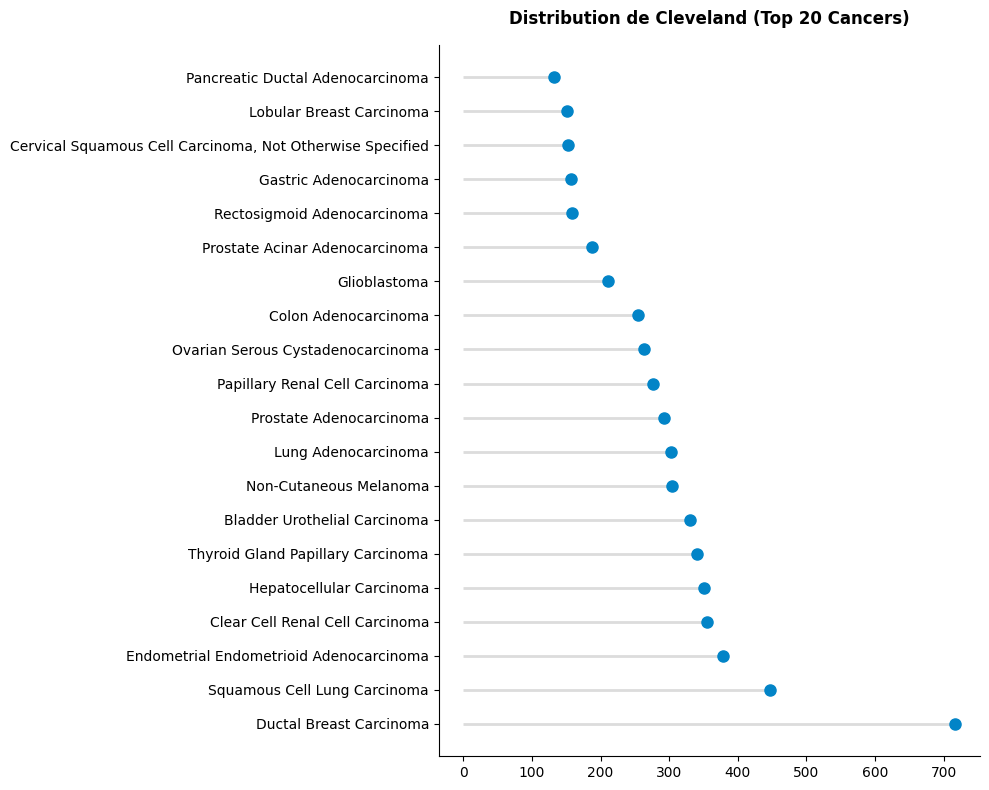

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Préparation des données
data_clean = df[CANCER_COL].value_counts().head(20).reset_index()
data_clean.columns = ['Cancer', 'Count']

fig, ax = plt.subplots(figsize=(10, 8))
# On trace la ligne de fond pour chaque cancer
ax.hlines(y=data_clean['Cancer'], xmin=0, xmax=data_clean['Count'], color='gainsboro', linewidth=2)
# On ajoute le point coloré au bout
ax.plot(data_clean['Count'], data_clean['Cancer'], "o", markersize=8, color="#0284C7")

ax.spines[['top', 'right']].set_visible(False)
ax.set_title("Distribution de Cleveland (Top 20 Cancers)", fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

In [16]:
import plotly.express as px

# On prend les lignes sans données manquantes pour ces trois colonnes
df_sunburst = df[[TOPO_COL, CANCER_COL]].dropna()
# On limite aux catégories majeures pour que ce soit lisible
top_topos = df_sunburst[TOPO_COL].value_counts().head(10).index
df_filtered = df_sunburst[df_sunburst[TOPO_COL].isin(top_topos)]

fig = px.sunburst(
    df_filtered, 
    path=[TOPO_COL, CANCER_COL], 
    title="<b>Hiérarchie Clinique : Topographie ➔ Type de Cancer</b>",
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.write_html("sunburst_hierarchy.html")
fig.show()

In [17]:
import pandas as pd
import plotly.graph_objects as go

# 1. Sélection des colonnes clés et suppression des données manquantes
# On utilise la table 'exploded' si tes échantillons appartiennent à plusieurs cohortes
df_sankey = exploded[['cohort_names', TOPO_COL, CANCER_COL]].dropna().copy()

# 2. Filtrage pour garder le graphique propre et lisible (Évite l'effet spaghettis)
top_cohorts = df_sankey['cohort_names'].value_counts().head(10).index
top_topos = df_sankey[TOPO_COL].value_counts().head(10).index

df_filtered = df_sankey[
    df_sankey['cohort_names'].isin(top_cohorts) & 
    df_sankey[TOPO_COL].isin(top_topos)
].copy()

# 3. Préparation des flux (Étape 1 : Cohorte -> Topographie)
flow1 = df_filtered.groupby(['cohort_names', TOPO_COL]).size().reset_index(name='value')
flow1.columns = ['source', 'target', 'value']

# Préparation des flux (Étape 2 : Topographie -> Type de Cancer)
flow2 = df_filtered.groupby([TOPO_COL, CANCER_COL]).size().reset_index(name='value')
flow2.columns = ['source', 'target', 'value']

# Combinaison de tous les flux en un seul tableau de liaisons
all_flows = pd.concat([flow1, flow2], ignore_index=True)

# 4. Indexation unique de tous les nœuds (Chaque texte doit avoir un numéro ID unique)
unique_nodes = list(pd.unique(all_flows[['source', 'target']].values.ravel()))
node_indices = {node: idx for idx, node in enumerate(unique_nodes)}

# Remplacement des textes par leurs ID numériques pour Plotly
all_flows['source_id'] = all_flows['source'].map(node_indices)
all_flows['target_id'] = all_flows['target'].map(node_indices)

# 5. Construction du graphique de Sankey avec des couleurs douces
fig = go.Figure(data=[go.Sankey(
    node = dict(
        pad = 18,
        thickness = 20,
        line = dict(color = "black", width = 0.3),
        label = unique_nodes,
        color = "#6366F1"  # Couleur moderne pour les blocs verticaux
    ),
    link = dict(
        source = all_flows['source_id'],
        target = all_flows['target_id'],
        value = all_flows['value'],
        color = "rgba(226, 232, 240, 0.6)"  # Liens gris clairs semi-transparents
    )
)])

# Mise en page générale
fig.update_layout(
    title_text="<b>Flux des Données Cliniques : Cohortes ➔ Topographies ➔ Types de Cancers</b>",
    font_size=11,
    width=1300,
    height=800
)

# 6. Sauvegarde et affichage
output_html = "clinical_data_sankey_flow.html"
fig.write_html(output_html)
print(f"📊 Diagramme de Sankey sauvegardé avec succès : {output_html}")
fig.show()

📊 Diagramme de Sankey sauvegardé avec succès : clinical_data_sankey_flow.html


💾 Graphique simplifié et lisible sauvegardé : affichage_clinique_ultra_lisible.png


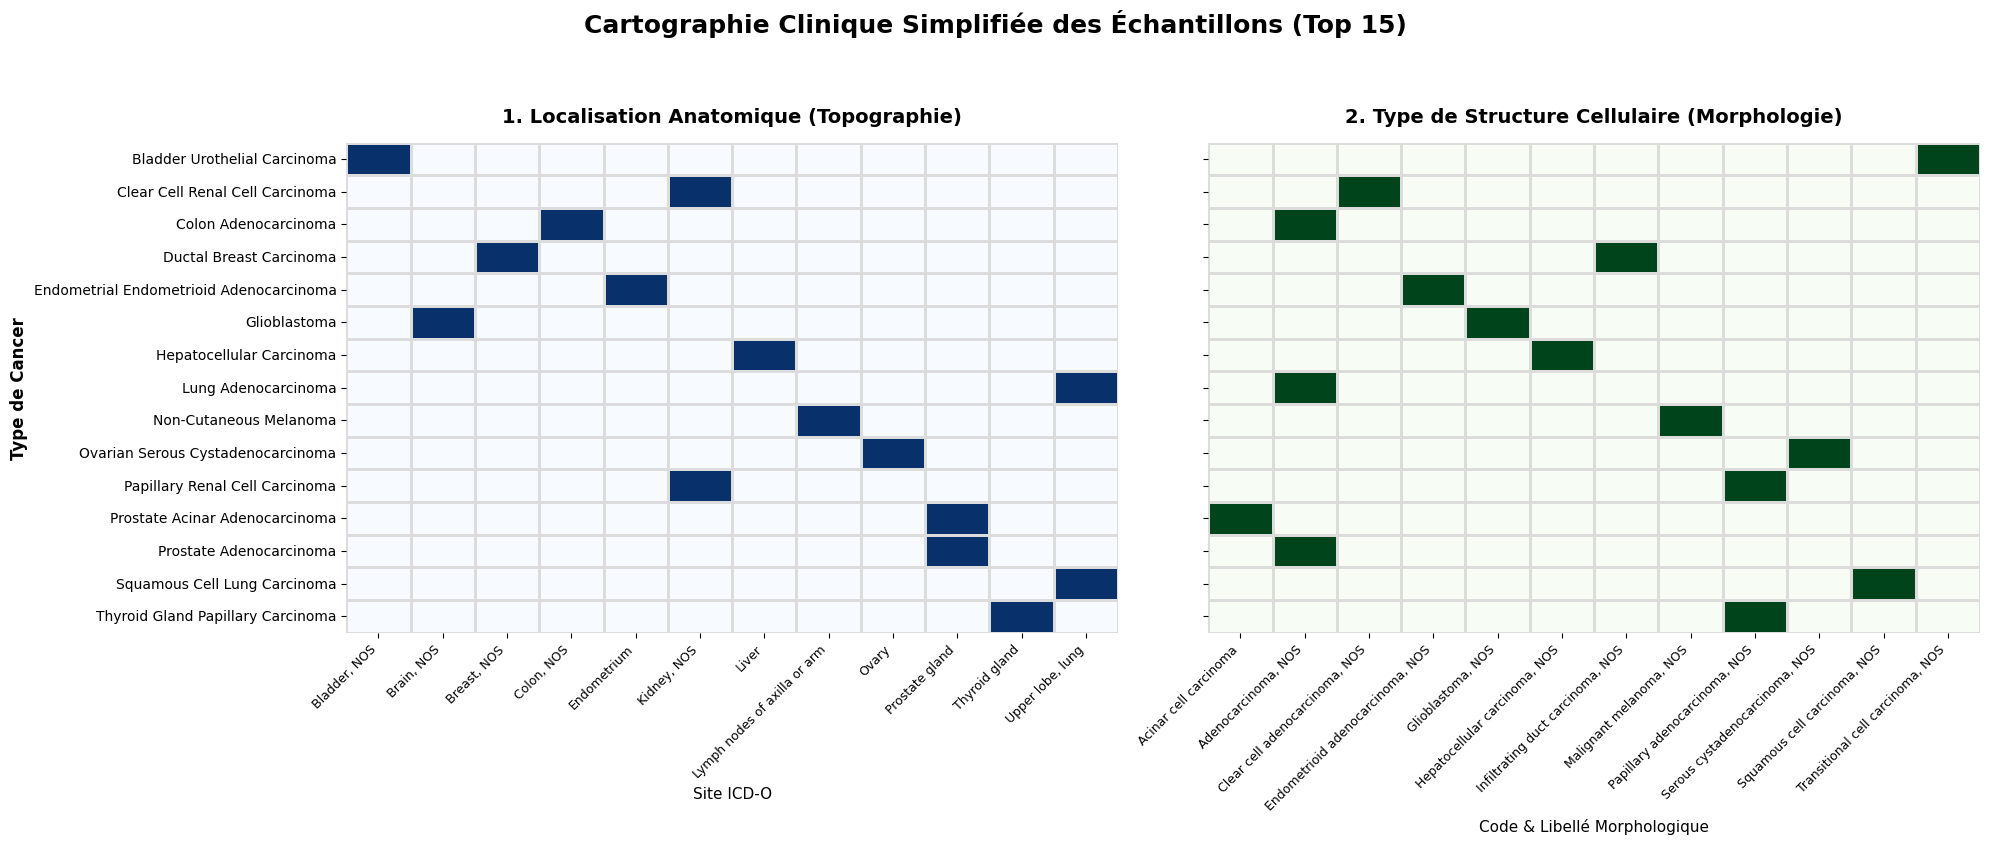

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sélection des Top 15 Cancers pour garder le graphique propre
top_cancers = df[CANCER_COL].value_counts().head(15).index
df_clean = df[df[CANCER_COL].isin(top_cancers)]

# 2. On extrait la correspondance unique (Cancer -> Topographie) et (Cancer -> Morphologie)
# On prend la catégorie la plus fréquente pour chaque cancer pour éviter les doublons
topo_map = df_clean.groupby(CANCER_COL)[TOPO_COL].agg(lambda x: x.value_counts().index[0])
morph_map = df_clean.groupby(CANCER_COL)[MORPH_COL].agg(lambda x: x.value_counts().index[0])

# 3. Création d'un DataFrame de synthèse propre
summary_df = pd.DataFrame({
    'Topographie (Site)': topo_map,
    'Morphologie (Cellules)': morph_map
})

# Pour l'affichage, on transforme cela en matrices binaires (0 ou 1)
topo_pivot = pd.crosstab(summary_df.index, summary_df['Topographie (Site)'])
morph_pivot = pd.crosstab(summary_df.index, summary_df['Morphologie (Cellules)'])

# 4. Configuration de la figure unique (2 panneaux côte à côte)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Panneau Gauche : Où se trouve le cancer ? (Topographie)
sns.heatmap(topo_pivot, cmap="Blues", cbar=False, linewidths=1, linecolor="gainsboro", ax=ax1)
ax1.set_title("1. Localisation Anatomique (Topographie)", fontsize=14, fontweight="bold", pad=15)
ax1.set_ylabel("Type de Cancer", fontsize=12, fontweight="bold")
ax1.set_xlabel("Site ICD-O", fontsize=11)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right", fontsize=9)

# Panneau Droit : À quoi ressemblent les cellules ? (Morphologie)
sns.heatmap(morph_pivot, cmap="Greens", cbar=False, linewidths=1, linecolor="gainsboro", ax=ax2)
ax2.set_title("2. Type de Structure Cellulaire (Morphologie)", fontsize=14, fontweight="bold", pad=15)
ax2.set_ylabel("") # On enlève l'axe Y pour ne pas répéter les cancers
ax2.set_xlabel("Code & Libellé Morphologique", fontsize=11)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax2.set_yticklabels([]) # Supprime les labels répétitifs au centre

# Ajustements pour éviter que les textes longs soient coupés
plt.suptitle("Cartographie Clinique Simplifiée des Échantillons (Top 15)", fontsize=18, fontweight="bold", y=1.05)
plt.tight_layout()

# Sauvegarde
plt.savefig("affichage_clinique_ultra_lisible.png", dpi=300, bbox_inches="tight")
print("💾 Graphique simplifié et lisible sauvegardé : affichage_clinique_ultra_lisible.png")
plt.show()